# Library Imports

In [1]:
# Baseline, Stats Forecast, and ML
!pip install statsforecast utilsforecast coreforecast mlforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
from utilsforecast.losses import bias, rmse, mae, mape, bias
from utilsforecast.evaluation import evaluate

In [3]:
#LGBM Imports
import lightgbm as lgb
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

# Import Data

In [39]:
df_base = pd.read_parquet('/content/sample_hotels-1.parquet')
df_base.head()

,unique_id,ds,holiday_flag,target_day,target_month,target_year,location_type,hotel_type,y,otb_1,...,otb_51,otb_52,otb_53,otb_54,otb_55,otb_56,otb_57,otb_58,otb_59,otb_60
1430,hotel_0,2022-01-01,no,Sat,Jan,2022,NonSuburban,Resorts & Destinations,0.975309,0.679012,...,0.197531,0.197531,0.197531,0.185185,0.160494,0.160494,0.160494,0.160494,0.160494,0.160494
1431,hotel_0,2022-01-02,no,Sun,Jan,2022,NonSuburban,Resorts & Destinations,0.493827,0.308642,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.061728,0.061728,0.049383
1432,hotel_0,2022-01-03,no,Mon,Jan,2022,NonSuburban,Resorts & Destinations,0.456790,0.358025,...,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691,0.024691
1433,hotel_0,2022-01-04,no,Tue,Jan,2022,NonSuburban,Resorts & Destinations,0.592593,0.419753,...,0.074074,0.074074,0.074074,0.074074,0.061728,0.061728,0.037037,0.037037,0.024691,0.024691
1434,hotel_0,2022-01-05,no,Wed,Jan,2022,NonSuburban,Resorts & Destinations,0.530864,0.407407,...,0.074074,0.074074,0.074074,0.074074,0.074074,0.049383,0.049383,0.024691,0.024691,0.012346


In [40]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10172 entries, 1430 to 298041
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   unique_id      10172 non-null  object        
 1   ds             10172 non-null  datetime64[us]
 2   holiday_flag   10172 non-null  object        
 3   target_day     10172 non-null  object        
 4   target_month   10172 non-null  object        
 5   target_year    10172 non-null  int32         
 6   location_type  10172 non-null  object        
 7   hotel_type     10172 non-null  object        
 8   y              10172 non-null  float64       
 9   otb_1          10172 non-null  float64       
 10  otb_2          10172 non-null  float64       
 11  otb_3          10172 non-null  float64       
 12  otb_4          10172 non-null  float64       
 13  otb_5          10172 non-null  float64       
 14  otb_6          10172 non-null  float64       
 15  otb_7          10172

In [41]:
hotels_to_drop = ['hotel_28', 'hotel_77']
df_base = df_base[df_base['unique_id'].isin(hotels_to_drop) == False]

In [7]:
# Verify that the specified hotels have been dropped from the DataFrame
print(f"'hotel_28' in unique_ids: {'hotel_28' in df_base['unique_id'].unique()}")
print(f"'hotel_77' in unique_ids: {'hotel_77' in df_base['unique_id'].unique()}")

'hotel_28' in unique_ids: False
'hotel_77' in unique_ids: False


# Data Preparation (this is shortened from first version)

In [42]:
df_base = df_base.drop(columns=['target_year'])

**Convert Categorical Variables into Dummy Variables**

In [43]:
 # Convert holiday flag to boolean manually
 df_base['holiday_flag'] = df_base['holiday_flag'].astype('bool')

In [45]:
cat_cols = [
    'target_day',
    'target_month',
    'location_type',
    'hotel_type'
]

for col in cat_cols:
    df_base[col] = df_base[col].astype('category')

In [46]:
df_base = pd.get_dummies(df_base, columns=cat_cols, drop_first=True)

In [44]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9282 entries, 1430 to 298041
Data columns (total 68 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   unique_id      9282 non-null   object        
 1   ds             9282 non-null   datetime64[us]
 2   holiday_flag   9282 non-null   bool          
 3   target_day     9282 non-null   object        
 4   target_month   9282 non-null   object        
 5   location_type  9282 non-null   object        
 6   hotel_type     9282 non-null   object        
 7   y              9282 non-null   float64       
 8   otb_1          9282 non-null   float64       
 9   otb_2          9282 non-null   float64       
 10  otb_3          9282 non-null   float64       
 11  otb_4          9282 non-null   float64       
 12  otb_5          9282 non-null   float64       
 13  otb_6          9282 non-null   float64       
 14  otb_7          9282 non-null   float64       
 15  otb_8          9282 n

In [12]:
# Drop all OTB values before otb_28 because that information wouldn't actually be available at the time of forecasting
# By only keeping otb_28 and beyond, I ensure the model doesn't "cheat" by looking at data from inside the 28-day period
columns_to_drop = [f'otb_{i}' for i in range(1, 28)]
df_base = df_base.drop(columns=columns_to_drop)
display(df_base.head())

,unique_id,ds,y,otb_28,otb_29,otb_30,otb_31,otb_32,otb_33,otb_34,...,target_month_Jun,target_month_Mar,target_month_May,target_month_Nov,target_month_Oct,target_month_Sep,location_type_NonSuburban,hotel_type_Key Central Business District,hotel_type_Other High Leisure Mix,hotel_type_Resorts & Destinations
1430,hotel_0,2022-01-01,0.975309,0.296296,0.283951,0.296296,0.296296,0.283951,0.259259,0.234568,...,False,False,False,False,False,False,True,False,False,True
1431,hotel_0,2022-01-02,0.493827,0.086420,0.086420,0.086420,0.086420,0.086420,0.086420,0.086420,...,False,False,False,False,False,False,True,False,False,True
1432,hotel_0,2022-01-03,0.456790,0.061728,0.061728,0.061728,0.061728,0.061728,0.061728,0.049383,...,False,False,False,False,False,False,True,False,False,True
1433,hotel_0,2022-01-04,0.592593,0.111111,0.111111,0.111111,0.111111,0.098765,0.098765,0.098765,...,False,False,False,False,False,False,True,False,False,True
1434,hotel_0,2022-01-05,0.530864,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,0.111111,...,False,False,False,False,False,False,True,False,False,True


**Test and Train Seperation**

In [13]:
cutoff = '2023-05-31'

train = df_base[df_base['ds'] <= cutoff]
test = df_base[df_base['ds'] > cutoff]

In [14]:
train.shape

(8772, 57)

In [15]:
test.shape

(510, 57)

**Separating Data for Nixtla and Machine Learning Models**

In [16]:
df_no_pred = df_base[['unique_id', 'ds', 'y']]

In [17]:
train_base = train[['unique_id', 'ds', 'y']] # Nixtila format dataset
train_ml = train.copy() # full dataset for ML

In [18]:
test_base = test[['unique_id', 'ds', 'y']]
test_ml = test.copy()

# LightGBM Model

In [19]:
# Define Model
lgb_model = [
    lgb.LGBMRegressor(verbosity=-1) # you can include more models here
]

In [20]:
# Initiate MLForecast object
mlf_lgb = MLForecast(
    models=lgb_model,
    freq='D',
    lags = [range(28, 56)].append([60, 90]),
    # 28-56 lags provides the model with a 4-week window of daily patterns (from 4 to 8 weeks ago) to learn from without 'cheating' on our 28-day forecast horizon
    # 60 and 90-day lags to give the model more perspective on the season's paterns, helping it see if demand is trending up or down compared to 2 or 3 months ago
    # Excluded the 365-day lag because it would have forced us to throw away a full year of our limited history, leaving the model with too little data to actually identify patterns
    lag_transforms = {
        28: [ # transforming the 28th day so model can use 7 and 14 day rolling averages of the 2 weeks leading up to the cutoff
            RollingMean(window_size=7),
            RollingMean(window_size = 14)
        ]
    },
    date_features=['dayofweek', 'month'],
    # Given possible weekly seasonality observed in exploratory plot, included day of week to capture weekend vs weekday influence and
    # Month features to account for broader seasonal influences, especially since we excluded a 365 lag

)

In [21]:
mlf_lgb.fit(train_ml, static_features = [])

MLForecast(models=[LGBMRegressor], freq=D, lag_features=['rolling_mean_lag28_window_size7', 'rolling_mean_lag28_window_size14'], date_features=['dayofweek', 'month'], num_threads=1)

In [22]:
# Drop 'y' column and limit to horizon window
test_prepared = test_ml.drop(columns=['y'])
test_prepared = test_prepared.groupby('unique_id').head(n=28).reset_index(drop=True)

In [25]:
# Make predictions
lgb_preds = mlf_lgb.predict(28, X_df=test_prepared)

# Save as CVS
lgb_preds.to_csv('lgb_final_preds.csv')

In [ ]:
lgb_preds.head()

,unique_id,ds,LGBMRegressor
0,hotel_0,2023-06-01,0.751502
1,hotel_0,2023-06-02,0.767410
2,hotel_0,2023-06-03,0.878731
3,hotel_0,2023-06-04,0.565602
4,hotel_0,2023-06-05,0.657339


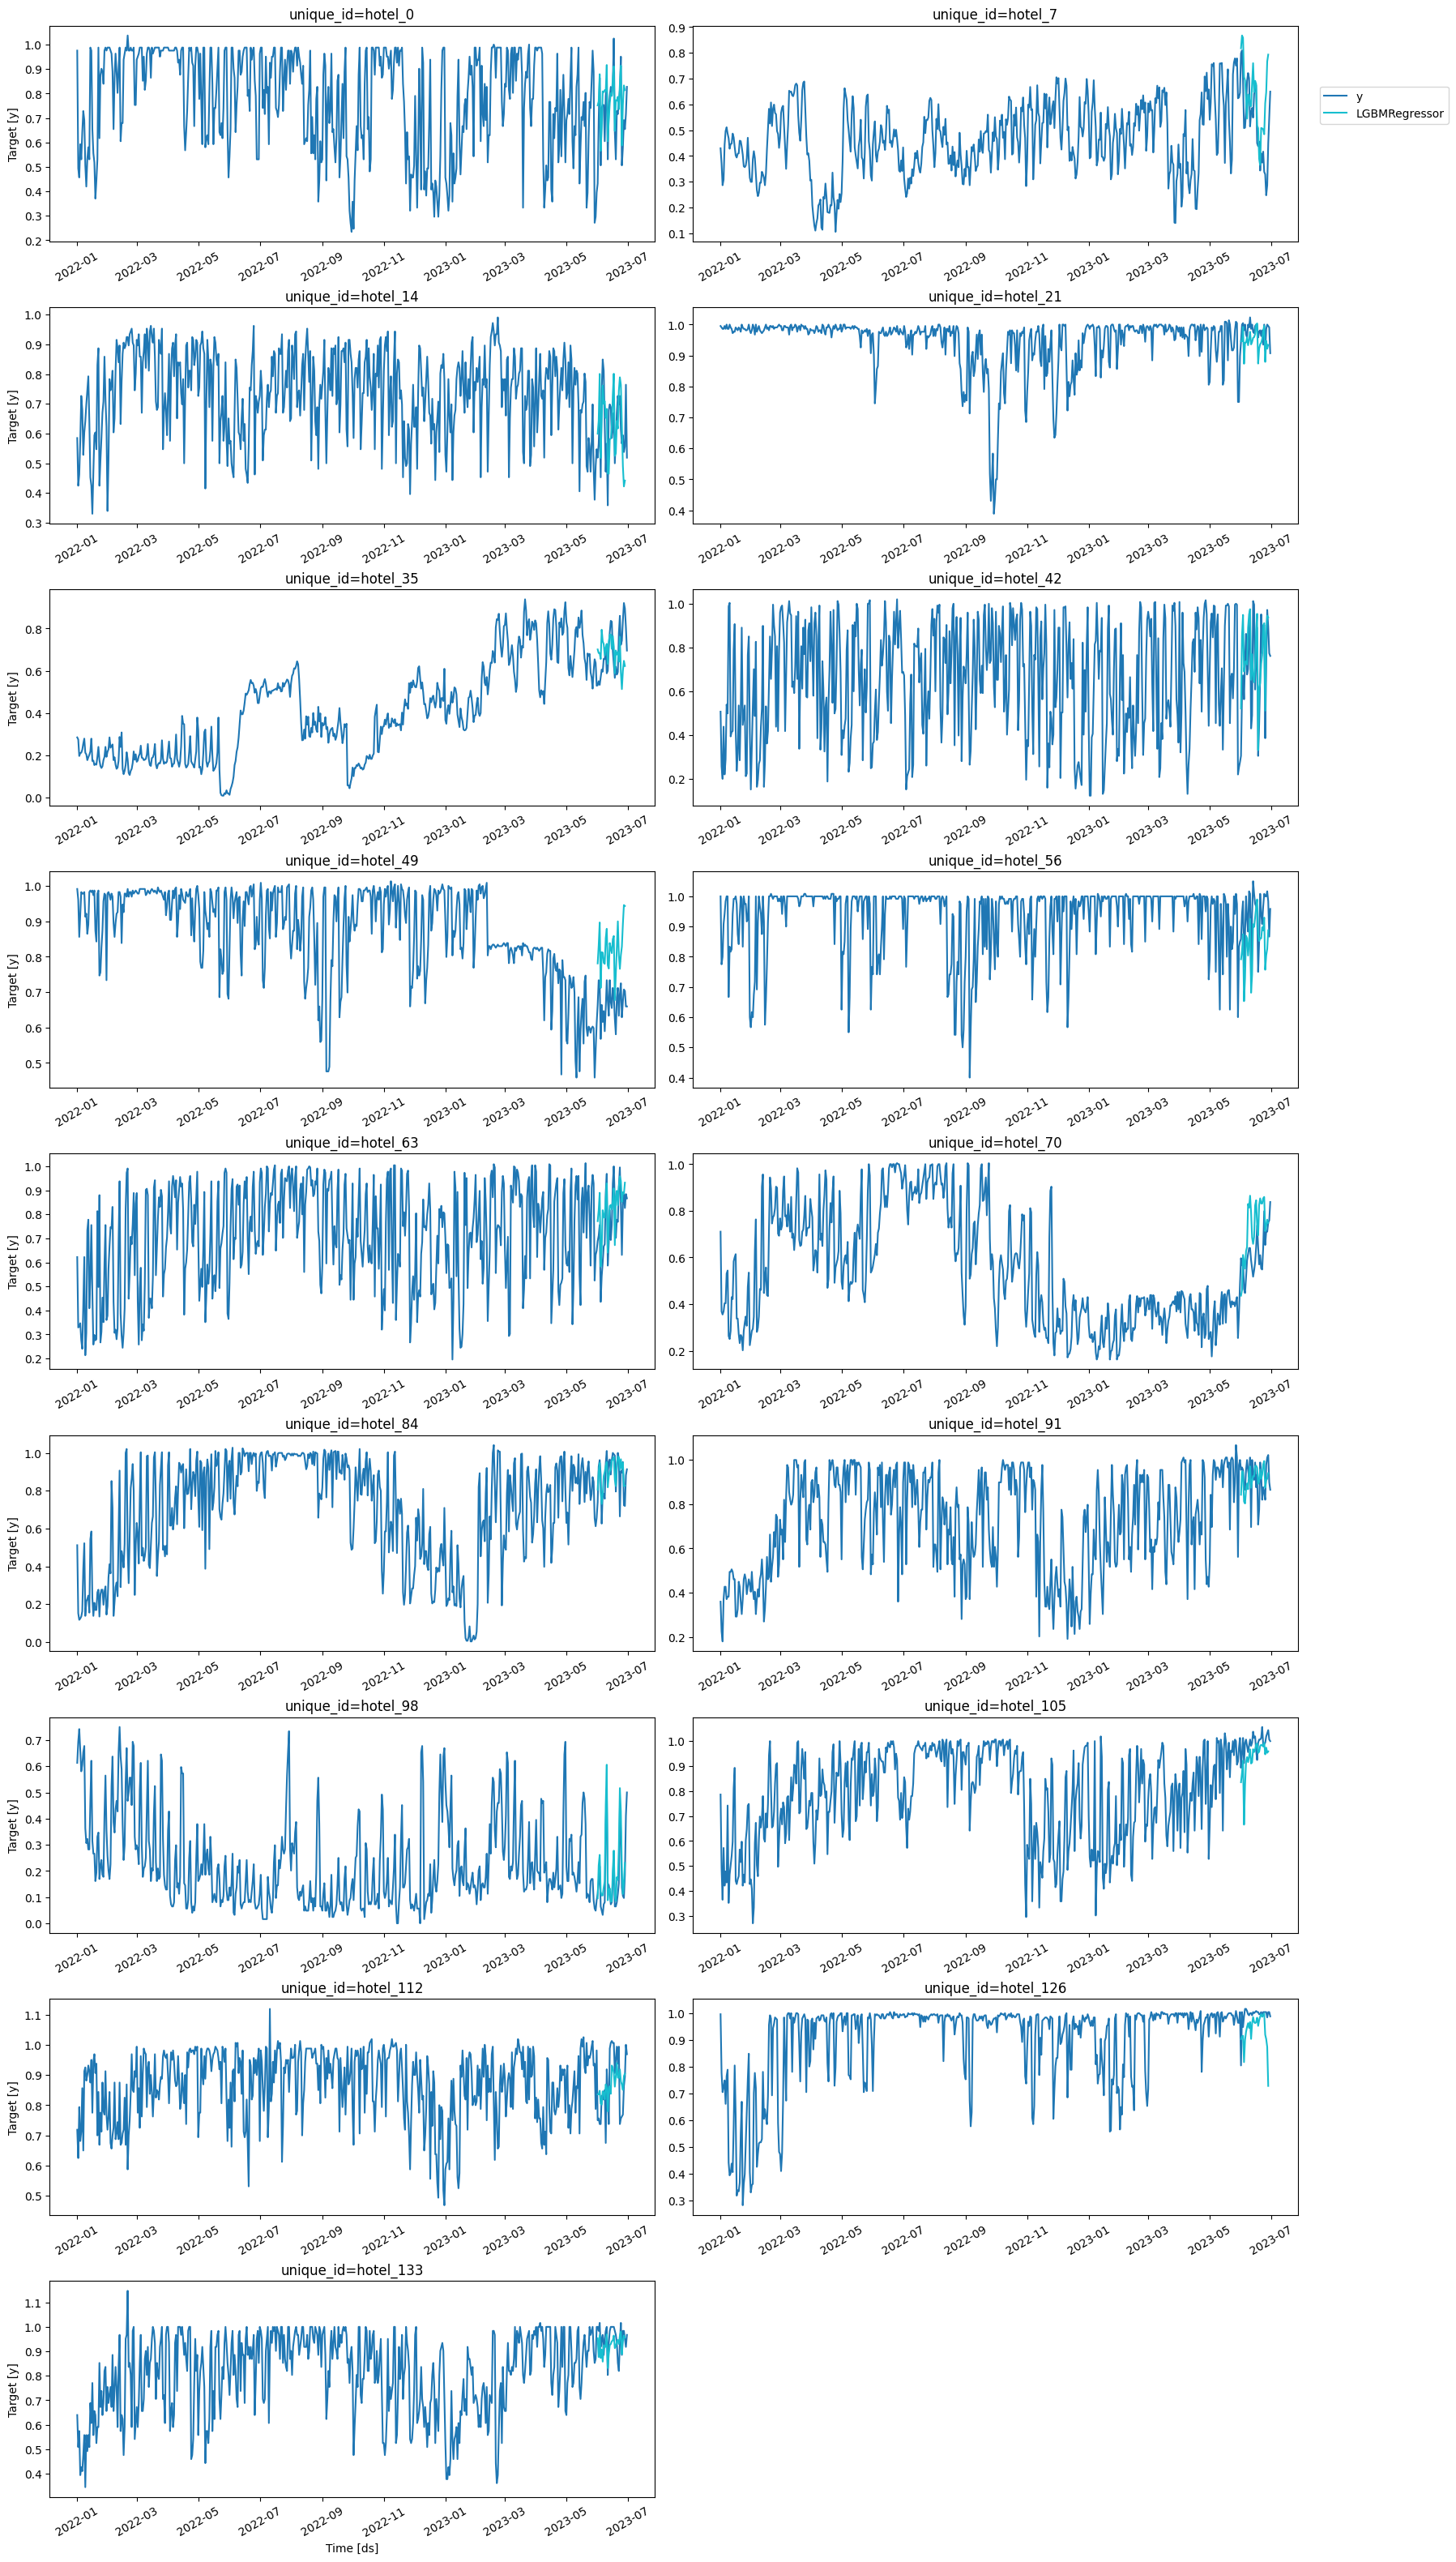

In [24]:
# plotting actual vs prediction
fig = plot_series(df_no_pred, lgb_preds, max_ids=17)
display(fig)